# ECG — Preencher falhas ligando último ao próximo pixel válido

1. Carregar a imagem do ECG;
2. Pré-processar e extrair o traçado (preto) com a grade atenuada;
3. Detectar faixas horizontais (derivações);
4. Preencher falhas por **interpolação linear coluna a coluna** dentro de cada faixa;
5. Visualizar todas as etapas e salvar os resultados.

**Entrada**: `/mnt/data/img20250221_10384557.png`

In [1]:
import cv2, os, numpy as np, matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from skimage.morphology import remove_small_objects, skeletonize
from skimage.measure import label, regionprops
from skimage.util import img_as_bool

IMG_PATH = 'bucket/img20250225_11454133.png'
assert os.path.exists(IMG_PATH), f'Imagem não encontrada: {IMG_PATH}'

def imshow(img, title=None, cmap=None, size=(16,6)):
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap if cmap else 'gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if title: plt.title(title)
    plt.axis('off'); plt.show()


Tamanho original: (2680, 5976)


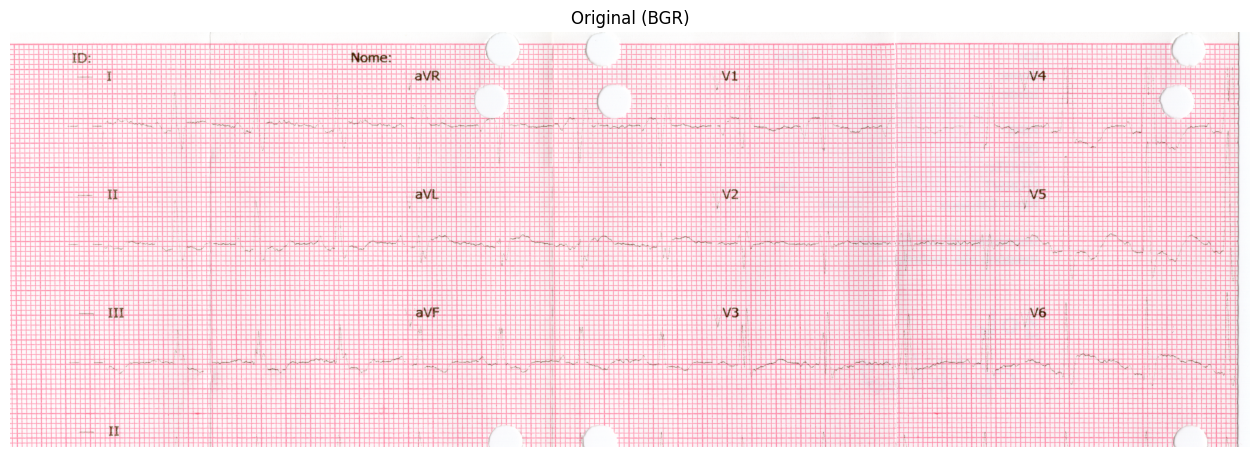

In [2]:
img = cv2.imread(IMG_PATH)
orig_h, orig_w = img.shape[:2]
img = img[0:2000,:]
print('Tamanho original:', (orig_h, orig_w))
imshow(img, 'Original (BGR)')


## 1) Pré-processamento e máscara do traçado
- Reduzir saturação no HSV;
- Usar condição de **preto**: baixa intensidade no **cinza** *e* baixo canal **R** para evitar capturar a grade.


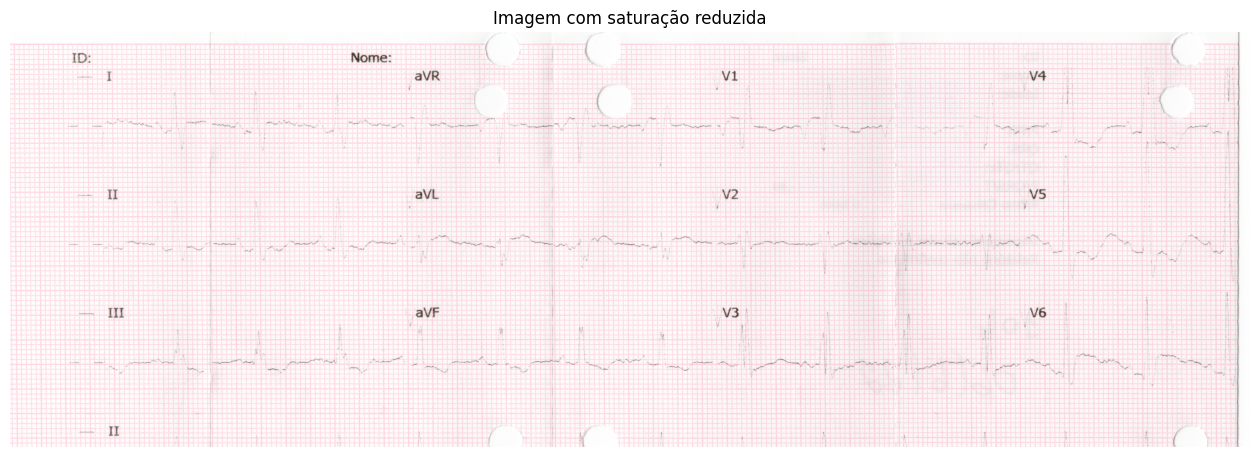

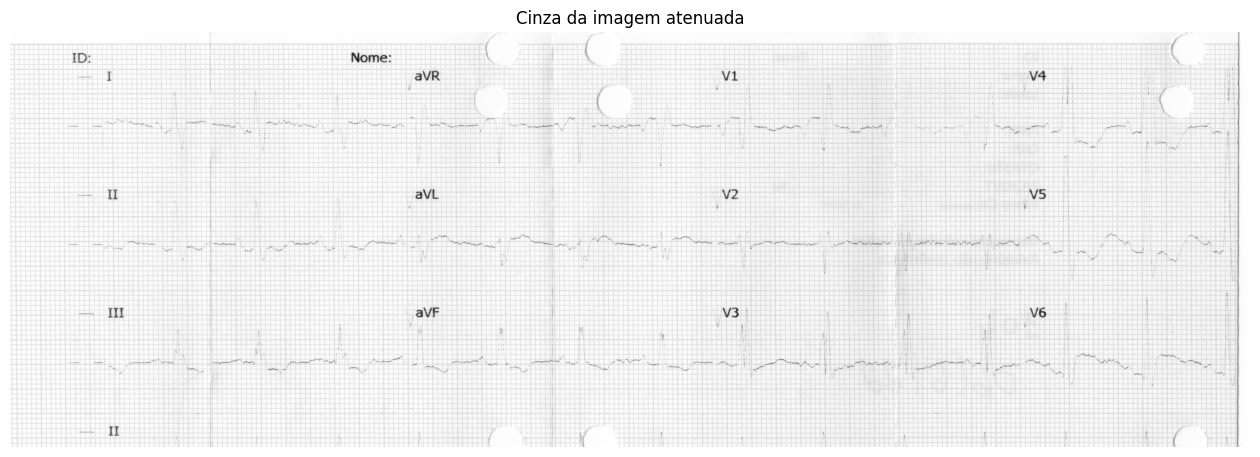

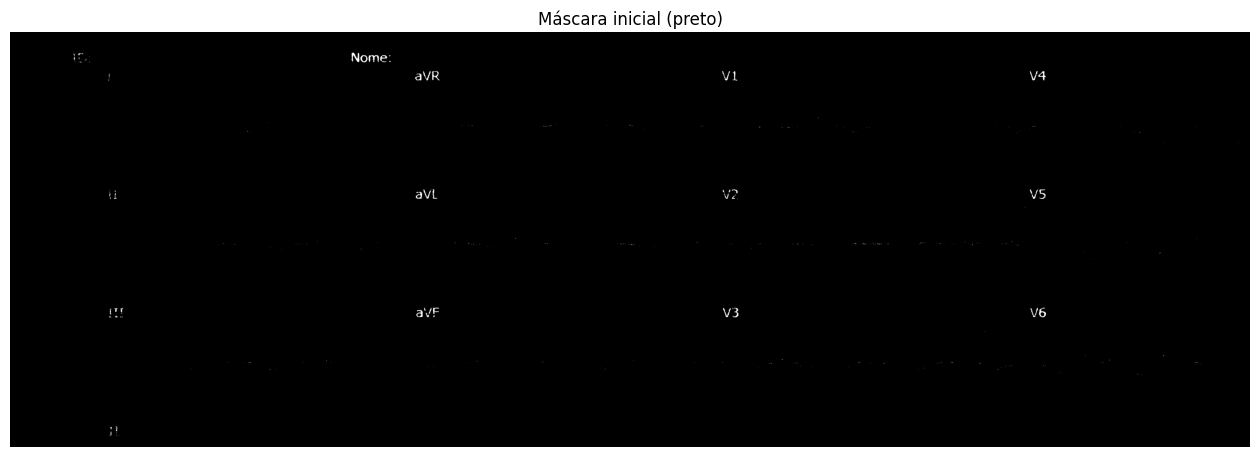

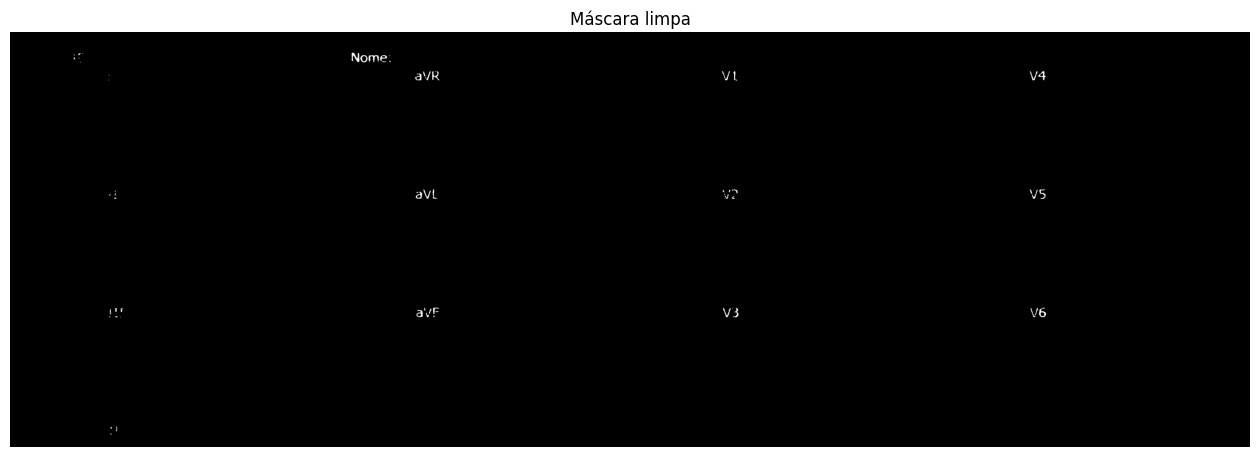

In [3]:
# Atenuar a grade via HSV (reduz saturação)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
h, s, v = cv2.split(hsv); s *= 0.4
atten = cv2.cvtColor(cv2.merge([h, s, v]).astype(np.uint8), cv2.COLOR_HSV2BGR)
gray = cv2.cvtColor(atten, cv2.COLOR_BGR2GRAY)
b,g,r = cv2.split(atten)

# Máscara de traçado preto: baixo cinza e baixo R
gray_thr = np.percentile(gray, 20)  # limiar robusto
mask_black = (gray < gray_thr) & (r < 120)
mask_black = mask_black.astype(np.uint8)*255

# Limpeza morfológica
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
mask_clean = cv2.morphologyEx(mask_black, cv2.MORPH_OPEN, kernel, iterations=1)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel, iterations=1)

imshow(atten, 'Imagem com saturação reduzida')
imshow(gray, 'Cinza da imagem atenuada')
imshow(mask_black, 'Máscara inicial (preto)')
imshow(mask_clean, 'Máscara limpa')


## 2) Detectar faixas horizontais com traçado (derivações)
Projetamos a máscara verticalmente e encontramos regiões com densidade de pixels pretos acima de um limiar.

Faixas detectadas: [(np.int64(102), np.int64(148)), (np.int64(187), np.int64(236)), (np.int64(756), np.int64(808)), (np.int64(1326), np.int64(1379))]


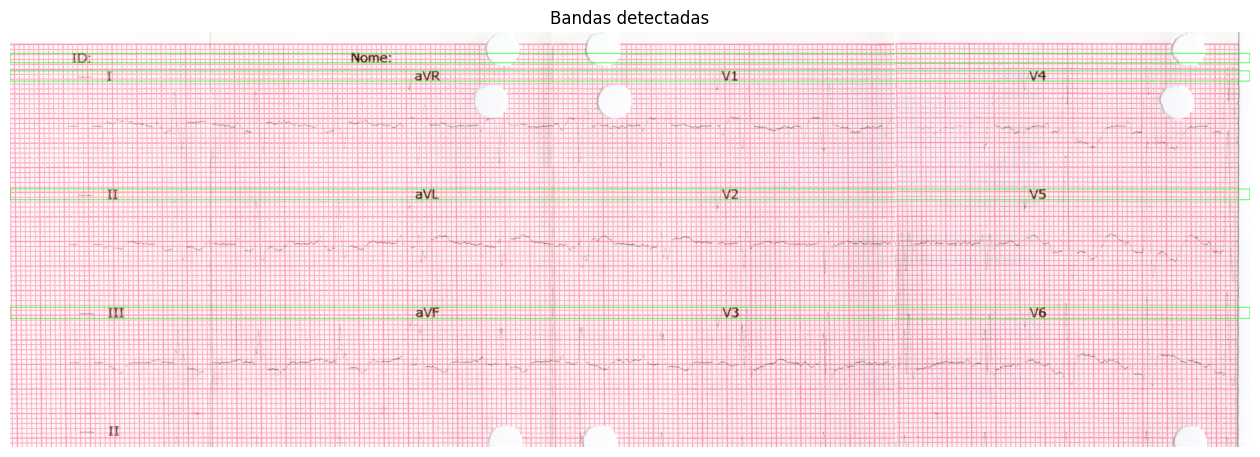

In [4]:
proj = mask_clean.sum(axis=1).astype(np.float32)
proj_s = gaussian_filter1d(proj, sigma=5)
thr = 0.2 * proj_s.max()
band_rows = (proj_s > thr).astype(np.uint8)

# Runs (start, end) onde proj acima do limiar
idx = np.where(np.diff(np.concatenate(([0], band_rows, [0]))))[0]
bands = [(idx[i], idx[i+1]) for i in range(0, len(idx), 2)]
# Filtrar bandas muito finas
bands = [b for b in bands if (b[1]-b[0]) > 40]
print('Faixas detectadas:', bands)

# Visualização das bandas
band_vis = img.copy()
for (y0,y1) in bands:
    cv2.rectangle(band_vis, (0,y0), (img.shape[1]-1, y1), (0,255,0), 2)
imshow(band_vis, 'Bandas detectadas')


## 3) Preencher falhas por interpolação coluna a coluna (dentro de cada banda)
Para cada coluna **x** numa banda, encontramos as posições **y** do traçado (máscara=1). Usamos a **mediana** como centro do traçado.
Quando uma coluna não tem traçado (falha), conectamos **linearmente** o último y válido antes da lacuna ao próximo y válido após a lacuna.

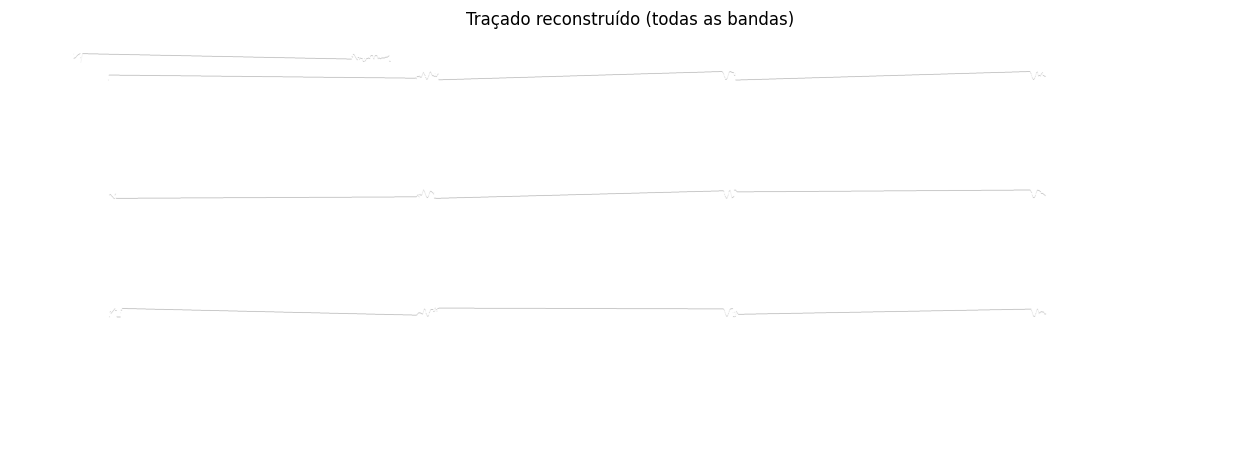

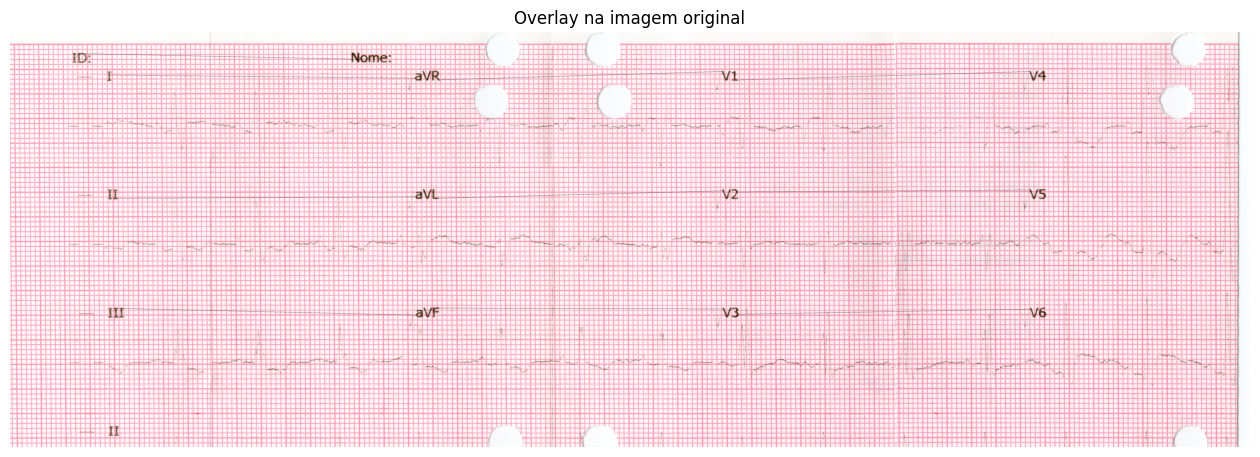

In [5]:
def interpolate_band(mask_band):
    H, W = mask_band.shape
    center = np.full(W, -1, dtype=np.int32)
    for x in range(W):
        ys = np.where(mask_band[:,x]>0)[0]
        if ys.size:
            center[x] = int(np.median(ys))
    # preencher lacunas
    x = 0
    while x < W:
        if center[x] != -1:
            x += 1; continue
        x0 = x-1
        while x0 >= 0 and center[x0]==-1:
            x0 -= 1
        x1 = x+1
        while x1 < W and center[x1]==-1:
            x1 += 1
        if x0 >= 0 and x1 < W and center[x0]!=-1 and center[x1]!=-1:
            y0, y1 = center[x0], center[x1]
            for xi in range(x0+1, x1):
                t = (xi-x0)/(x1-x0)
                center[xi] = int(round((1-t)*y0 + t*y1))
            x = x1
        else:
            # se não tem par válido, apenas pula
            x += 1
    return center

recon_canvas = np.ones_like(gray)*255
overlay = img.copy()

for (y0,y1) in bands:
    band_mask = mask_clean[y0:y1, :]
    ctr = interpolate_band(band_mask)
    # desenhar traçado reconstruído (linha fina)
    for x, y in enumerate(ctr):
        if y>=0:
            yy = y0 + y
            recon_canvas[yy, x] = 0
            cv2.circle(overlay, (x, yy), 0, (0,0,0), -1)

imshow(recon_canvas, 'Traçado reconstruído (todas as bandas)')
imshow(overlay, 'Overlay na imagem original')


In [6]:
""" out_dir = '/mnt/data/ecg_out'
os.makedirs(out_dir, exist_ok=True)
cv2.imwrite(os.path.join(out_dir, 'step_atten_bgr.png'), atten)
cv2.imwrite(os.path.join(out_dir, 'step_gray.png'), gray)
cv2.imwrite(os.path.join(out_dir, 'step_mask_initial.png'), mask_black)
cv2.imwrite(os.path.join(out_dir, 'step_mask_clean.png'), mask_clean)
cv2.imwrite(os.path.join(out_dir, 'step_bands.png'), band_vis)
cv2.imwrite(os.path.join(out_dir, 'reconstructed_trace.png'), recon_canvas)
cv2.imwrite(os.path.join(out_dir, 'overlay_on_original.png'), overlay)
print('Arquivos salvos em', out_dir) """


" out_dir = '/mnt/data/ecg_out'\nos.makedirs(out_dir, exist_ok=True)\ncv2.imwrite(os.path.join(out_dir, 'step_atten_bgr.png'), atten)\ncv2.imwrite(os.path.join(out_dir, 'step_gray.png'), gray)\ncv2.imwrite(os.path.join(out_dir, 'step_mask_initial.png'), mask_black)\ncv2.imwrite(os.path.join(out_dir, 'step_mask_clean.png'), mask_clean)\ncv2.imwrite(os.path.join(out_dir, 'step_bands.png'), band_vis)\ncv2.imwrite(os.path.join(out_dir, 'reconstructed_trace.png'), recon_canvas)\ncv2.imwrite(os.path.join(out_dir, 'overlay_on_original.png'), overlay)\nprint('Arquivos salvos em', out_dir) "